In [147]:
# STEP 1: IMPORT LIBS & SETUP
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import joblib

# Create required directories programmatically if they don't exist
os.makedirs('../models', exist_ok=True)
print("Environment and directories setup successfully!")

Environment and directories setup successfully!


In [148]:
# STEP 2: DATA LOADING & INSPECTION
df=pd.read_csv('../data/raw/ecommerce_sales_analytics_5000.csv')
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [149]:
print(df.head(5)) # View the first 5 records to understand what the columns look like

   order_id order_date  customer_id  ... delivery_days customer_rating  revenue
0     10001   1/1/2022         1102  ...            10             4.7  1883.20
1     10002   1/2/2022         1435  ...             6             3.9   304.10
2     10003   1/3/2022         1860  ...             6             2.5   644.35
3     10004   1/4/2022         1270  ...             6             1.6  2569.90
4     10005   1/5/2022         1106  ...             4             4.9   468.56

[5 rows x 12 columns]


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [151]:
print(df.info()) # Inspect column data types and check for missing (null) values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB
None


In [152]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [153]:
print(df.describe()) # View basic statistics summary of numeric columns

           order_id  customer_id  ...  customer_rating      revenue
count   5000.000000  5000.000000  ...      5000.000000  5000.000000
mean   12500.500000  1505.701200  ...         2.973980  1021.955148
std     1443.520003   290.836902  ...         1.157722   825.584219
min    10001.000000  1000.000000  ...         1.000000    11.210000
25%    11250.750000  1253.000000  ...         2.000000   354.527500
50%    12500.500000  1510.000000  ...         3.000000   796.650000
75%    13750.250000  1761.000000  ...         4.000000  1515.690000
max    15000.000000  1999.000000  ...         5.000000  4119.330000

[8 rows x 8 columns]


In [154]:
# STEP 3: FEATURE ENGINEERING
df['order_date']=pd.to_datetime(df['order_date']) # Convert the date column string into a Pandas Datetime object
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


In [155]:
# Extract numerical components from the date
df['order_year']=df['order_date'].dt.year
df['order_month']=df['order_date'].dt.month
df['order_day']=df['order_date'].dt.day
df['order_dow']=df['order_date'].dt.dayofweek # Day of the week: 0=Monday, 6=Sunday

print("Data features extracted successfully!")
df.head()

Data features extracted successfully!


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_day,order_dow
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,1,5
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,2,6
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,3,0
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,4,1
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,5,2


In [156]:
#STEP 4: DATA SPLITTING

target_column='customer_rating' # Define target variable (what we want to predict)

In [157]:
# Define input features (drop structural IDs and the target itself)
feature_columns=[
    'product_category','region','quantity','unit_price','discount','payment_method','delivery_days','revenue','order_month','order_day','order_dow'
]

In [158]:
X=df[feature_columns]
y=df[target_column]

In [159]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (4000, 11)
Testing features shape: (1000, 11)


Text(0, 0.5, 'Count')

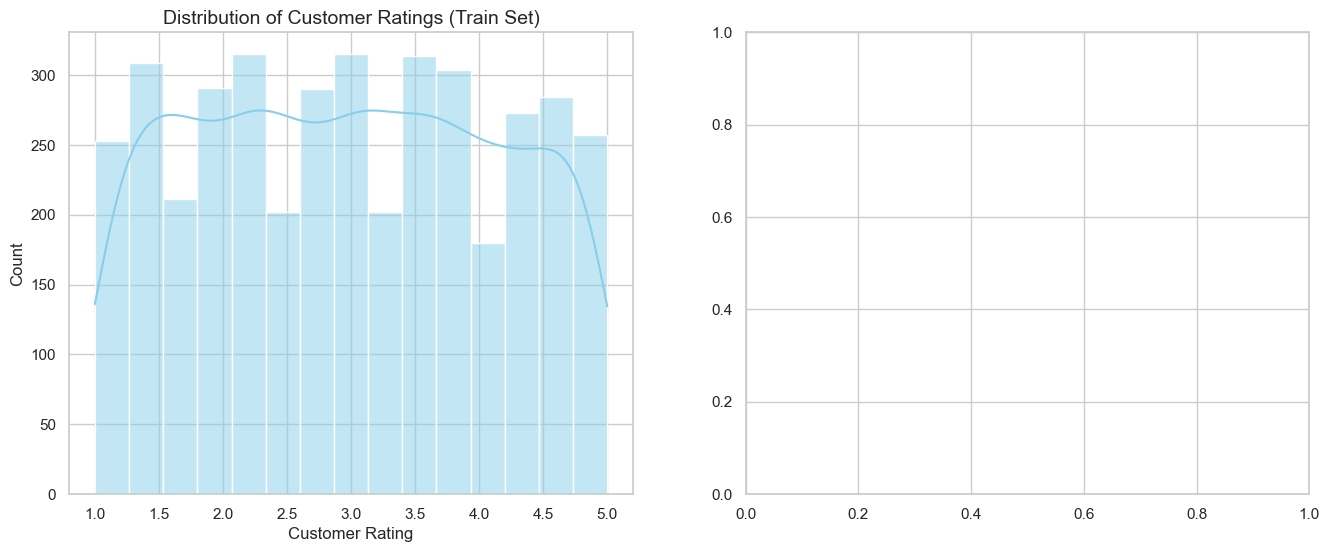

In [160]:
# STEP 5a: DATA VISUALIZATION (EXPLORATION)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") # Set a clean, modern aesthetic style for the plots
fig,axes=plt.subplots(1,2,figsize=(16,6)) # Create a figure canvas with 1 row and 2 columns of subplots

# Plot 1: Target Variable Distribution in Training Set
# Why: To check if customer ratings are heavily skewed or balanced
sns.histplot(y_train,bins=15,kde=True,ax=axes[0],color='skyblue')
axes[0].set_title('Distribution of Customer Ratings (Train Set)',fontsize=14)
axes[0].set_xlabel('Customer Rating',fontsize=12)
axes[0].set_ylabel('Count',fontsize=12)

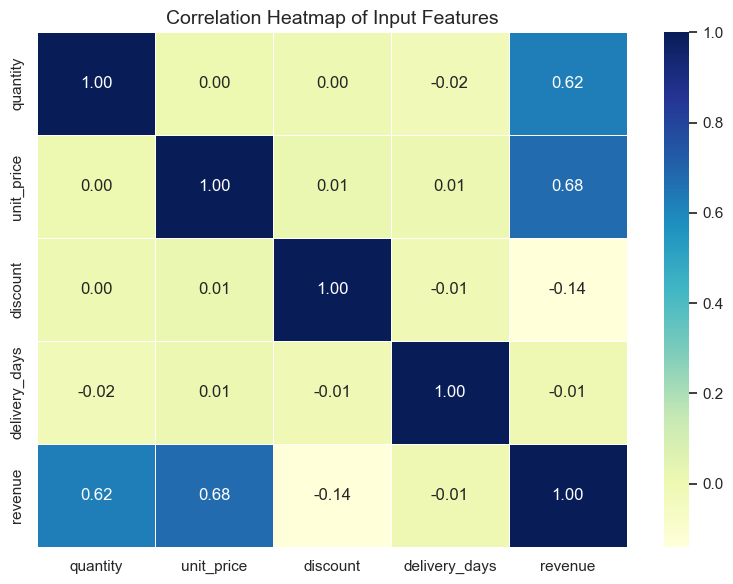

In [161]:
# Plot 2: Correlation Matrix Heatmap of Numerical Features in X_train
# Why: To see which numeric variables share linear relationships
numeric_cols = ['quantity', 'unit_price', 'discount', 'delivery_days', 'revenue']
correlation_matrix = X_train[numeric_cols].corr()

# Set the figure size explicitly for this single plot
plt.figure(figsize=(8, 6))

# Plot without defining an 'ax' parameter (it automatically targets the figure above)
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Input Features', fontsize=14)
plt.tight_layout()
plt.show()

In [162]:
# STEP 5b: DATA PREPROCESSING
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features=['product_category','region','payment_method']
numerical_features=['quantity','unit_price','discount','delivery_days','revenue']

# 2. Build the transformer pipeline configuration
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_features),
        ('cat',OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

# 3. Fit on training inputs and calculate scaling attributes, then apply transformation
X_train_transformed=preprocessor.fit_transform(X_train)

# 4. Transform testing inputs with the exact mathematical bounds established from training
X_test_transformed=preprocessor.transform(X_test)

print("Data Preprocessing completed successfully!")

Data Preprocessing completed successfully!


In [163]:
# STEP 6: MODEL TRAINING
from sklearn.ensemble import RandomForestRegressor

# Initialize the model blueprint
# n_estimators=100 sets up an ensemble of 100 individual decision trees working together
model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1) # n_jobs=-1 uses all available CPU cores for faster training

# Fit the algorithm to study connections between input arrays and actual ratings
print("Training Random Forest model on processed training data...")
model.fit(X_train_transformed, y_train)
print("Model training finished successfully!")

Training Random Forest model on processed training data...
Model training finished successfully!


Mean Absolute Error (MAE) : 1.0397 stars
R squared Efficiency Score (R2) : -0.0446



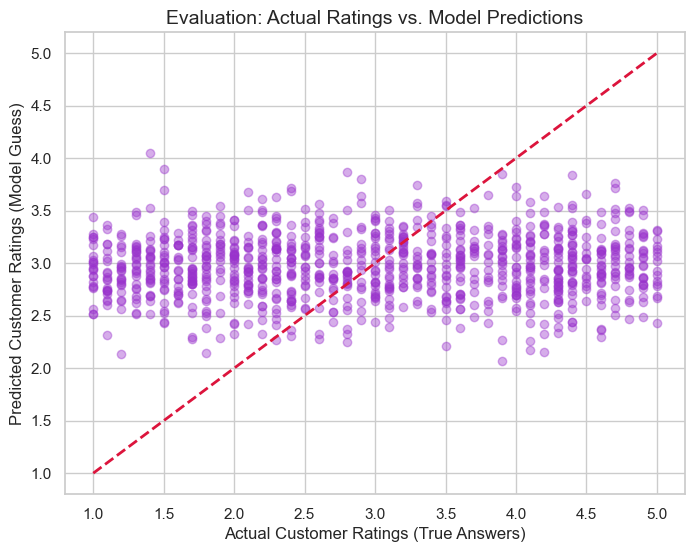

In [164]:
# STEP 7: EVALUATION & PERFORMANCE PLOTS
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

# 1. Generate predictions from the unseen test segment
y_pred=model.predict(X_test_transformed)

# 2. Extract mathematical validation values
mse=np.sqrt(mean_squared_error(y_test,y_pred))
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.4f} stars")
print(f"R squared Efficiency Score (R2) : {r2:.4f}\n")

# 3. Visualization: Plot Actual True Ratings vs. Model Predicted Ratings
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4,color='darkorchid')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],color='crimson', linestyle='--', lw=2)
plt.title("Evaluation: Actual Ratings vs. Model Predictions",fontsize=14)
plt.xlabel("Actual Customer Ratings (True Answers)",fontsize=12)
plt.ylabel("Predicted Customer Ratings (Model Guess)",fontsize=12)
plt.show()


In [165]:
# STEP 8: SAVE FINAL MODEL ARTIFACTS
import joblib
import os

# Using "../models" tells Python to go UP one directory level first
target_directory = "../models"

# 1. Ensure it targets your existing top-level folder
os.makedirs(target_directory, exist_ok=True)
# Export my trained mathematical rules to independent persistent files
joblib.dump(model, f"{target_directory}/final_model.pkl")
joblib.dump(preprocessor, f"{target_directory}/final_preprocessor.pkl")

['../models/final_preprocessor.pkl']